# Black-Scholes Explicit FDM Option Surfaces

Price vanilla call, vanilla put, and down-and-out call options, then plot their finite-difference surfaces.

In [2]:
import scipy as sp
from Bse_Explicit.plots import plot_bse

from Bse_Explicit.bse_explicit_call_put import bse_exp_call, bse_exp_put
from Bse_Explicit.down_out_call_put import bse_exp_down_out, plot_bse_down_out

In [3]:
sigma = 0.1730
risk_free_rate = 0.0375
time_to_exp = 0.0548
K = 275.00
S0 = 274.80
N = 25000
spatial_step = 0.75

## Vanilla Call and Put

In [4]:
call_Grid, call_T, call_S, call_time = bse_exp_call(
    sigma,
    risk_free_rate,
    time_to_exp,
    K,
    N,
    spatial_step,
    S0,
)
call_spl = sp.interpolate.CubicSpline(call_S, call_Grid[0, :])
call_price = float(call_spl(S0))

put_Grid, put_T, put_S, put_time = bse_exp_put(
    sigma,
    risk_free_rate,
    time_to_exp,
    K,
    N,
    spatial_step,
    S0,
)
put_spl = sp.interpolate.CubicSpline(put_S, put_Grid[0, :])
put_price = float(put_spl(S0))

print(f"Call price: {call_price:.6f} ({call_time:.3f}s)")
print(f"Put price:  {put_price:.6f} ({put_time:.3f}s)")

Call price: 4.620943 (37.678s)
Put price:  4.256398 (36.468s)


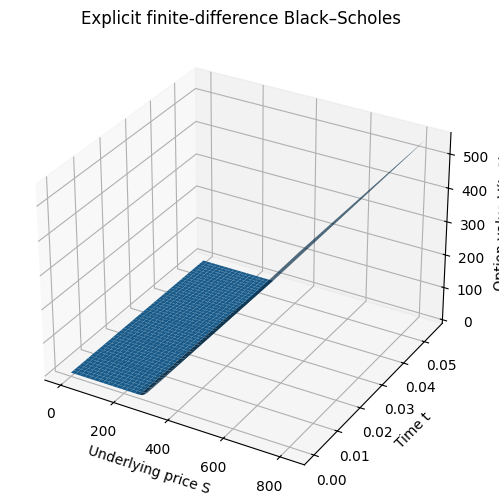

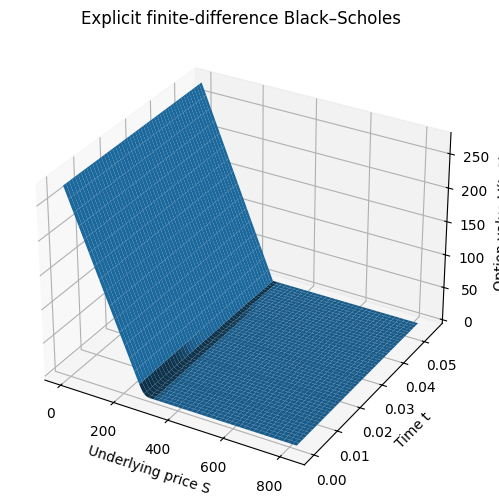

In [5]:

plot_bse(call_Grid, call_T, call_S)
plot_bse(put_Grid, put_T, put_S)

## Down-and-Out Call

In [6]:
barrier = 270.00

Grid, T, S, down_out_time = bse_exp_down_out(
    sigma,
    risk_free_rate,
    time_to_exp,
    K,
    N,
    spatial_step,
    S0,
    barrier,
)

spl = sp.interpolate.CubicSpline(S, Grid[0, :])
price = float(spl(S0))

print(f"Down-and-out call price: {price:.6f} ({down_out_time:.3f}s)")

Down-and-out call price: 3.424061 (34.589s)


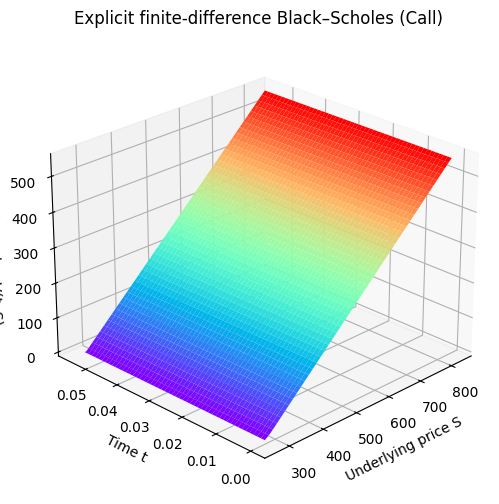

In [7]:
plot_bse_down_out(Grid, T, S)